In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:\\HEMNATH\\Support_Store_Analysis\\SuperStoreOrders.csv")
df.head()


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,1/6/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,1/8/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,1/5/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,1/5/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,1/8/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


# Data Cleaning

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [3]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])
df['sales'] = df['sales'].str.replace(',','')
df['sales'] = df['sales'].astype(float)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  float64       
 15  qu

In [5]:
df.describe()

,order_date,ship_date,sales,quantity,discount,profit,shipping_cost,year
count,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,2013-05-11 21:26:49.155780864,2013-05-15 20:42:42.745174528,246.498440,3.476545,0.142908,28.641740,26.375915,2012.777208
min,2011-01-01 00:00:00,2011-01-03 00:00:00,0.000000,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2012-06-19 00:00:00,2012-06-23 00:00:00,31.000000,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,2013-07-08 00:00:00,2013-07-12 00:00:00,85.000000,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,2014-05-22 00:00:00,2014-05-26 00:00:00,251.000000,5.000000,0.200000,36.810000,24.450000,2014.000000
max,2014-12-31 00:00:00,2015-01-07 00:00:00,22638.000000,14.000000,0.850000,8399.976000,933.570000,2014.000000
std,NaN,NaN,487.567175,2.278766,0.212280,174.424113,57.296804,1.098931


In [6]:
df.duplicated().sum()


np.int64(0)

In [7]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [8]:
df.isnull().any()

order_id          False
order_date        False
ship_date         False
ship_mode         False
customer_name     False
segment           False
state             False
country           False
market            False
region            False
product_id        False
category          False
sub_category      False
product_name      False
sales             False
quantity          False
discount          False
profit            False
shipping_cost     False
order_priority    False
year              False
dtype: bool

In [9]:
for data in df.columns:
    print(f"{data}: {df[data].nunique()}")


order_id: 25035
order_date: 1430
ship_date: 1464
ship_mode: 4
customer_name: 795
segment: 3
state: 1094
country: 147
market: 7
region: 13
product_id: 10292
category: 3
sub_category: 17
product_name: 3788
sales: 2246
quantity: 14
discount: 27
profit: 24575
shipping_cost: 10037
order_priority: 4
year: 4


In [10]:
Categorie_columns = ['ship_mode', 'segment', 'market', 'region', 'category', 'sub_category', 'order_priority', 'year']

for col in Categorie_columns:
    print(f"{col}: {df[col].unique()}")

ship_mode: ['Standard Class' 'Second Class' 'Same Day' 'First Class']
segment: ['Consumer' 'Home Office' 'Corporate']
market: ['Africa' 'APAC' 'EMEA' 'EU' 'Canada' 'LATAM' 'US']
region: ['Africa' 'Oceania' 'EMEA' 'North' 'Canada' 'Southeast Asia' 'Central'
 'South' 'Caribbean' 'North Asia' 'East' 'West' 'Central Asia']
category: ['Office Supplies' 'Furniture' 'Technology']
sub_category: ['Storage' 'Supplies' 'Paper' 'Furnishings' 'Machines' 'Appliances'
 'Copiers' 'Chairs' 'Tables' 'Bookcases' 'Phones' 'Accessories' 'Labels'
 'Art' 'Envelopes' 'Fasteners' 'Binders']
order_priority: ['Medium' 'High' 'Critical' 'Low']
year: [2011 2012 2013 2014]


# Sales Trend

In [11]:
#Total sales
print("Total_sales: ",df['sales'].sum())

Total_sales:  12642905.0


Text(0.5, 1.0, 'Sales by year')

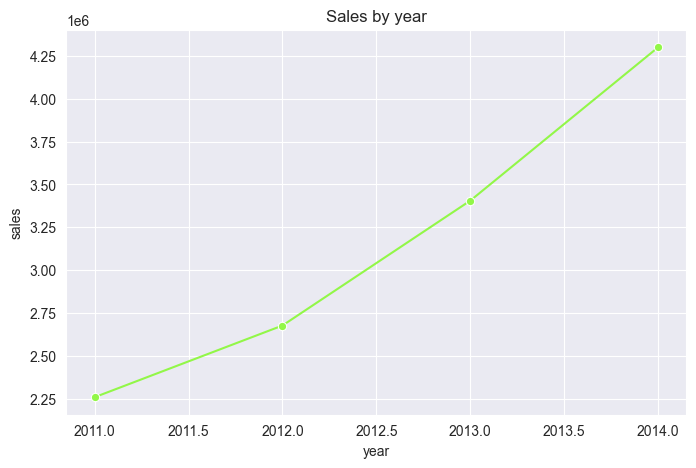

In [12]:
#Sales by year
sns.set_style("darkgrid")
plt.figure(figsize=(8,5))

Sales_by_year = df.groupby('year')['sales'].sum().reset_index()

sns.lineplot(
    data = Sales_by_year ,
    x= 'year',
    y = 'sales',
    marker = 'o',
    color="#92F748")

plt.title('Sales by year')


In [13]:
#Sales percent by year
df.groupby('year')['sales'].sum()/df['sales'].sum()*100

year
2011    17.871771
2012    21.177831
2013    26.938904
2014    34.011495
Name: sales, dtype: float64

In [14]:
#Sales percent by categoryr
df.groupby('category')['sales'].sum()/df['sales'].sum()*100

category
Furniture          32.515344
Office Supplies    29.956169
Technology         37.528487
Name: sales, dtype: float64

Sales increased by 34% in 2014, likely driven by higher orders in the Technology category

# Profit Analysis

Text(0.5, 1.0, 'Profit by Year')

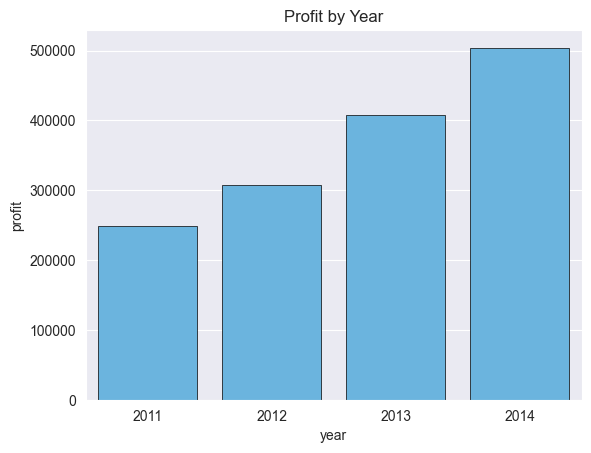

In [15]:
#Profit by year

Profit_by_year =df.groupby('year')['profit'].sum().round(2).sort_values(ascending=False).reset_index()

sns.barplot(
    Profit_by_year,
    x='year',
    y= 'profit',
    color="#58B9F1",
    edgecolor='black',
    linewidth=0.5)
plt.title('Profit by Year')

In [16]:
#Profit percent by year
df.groupby('year')['profit'].sum()/df['profit'].sum()

year
2011    0.169459
2012    0.209263
2013    0.278082
2014    0.343195
Name: profit, dtype: float64

In [17]:
#Sales percent by categoryr
df.groupby('category')['profit'].sum()/df['profit'].sum()*100

category
Furniture          19.521815
Office Supplies    35.293502
Technology         45.184683
Name: profit, dtype: float64

Profit increased by 34% in 2014, primarily driven by strong sales growth in the Technology category, which typically has higher margins compared to other categories. 

# Sales and Profit

Text(0.5, 1.0, 'Sales and Profit')

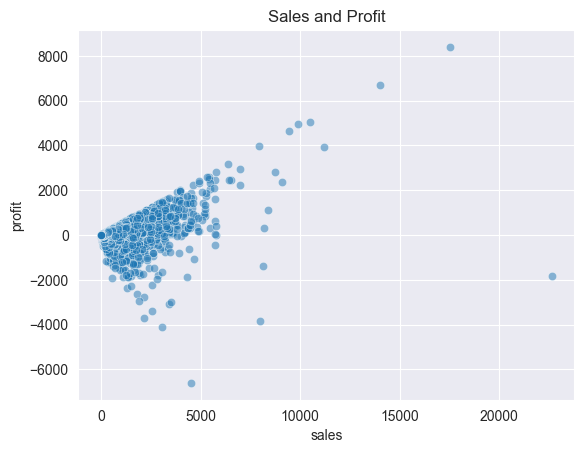

In [18]:
sns.scatterplot(data=df , x= df['sales'], y =df['profit'], alpha=0.5 )
plt.title("Sales and Profit")

In [19]:
#Sales and Profit by Region
df_grouped = df.groupby('region').agg({ 'sales' :'sum', 'profit':'sum'}).round(2)

# Convert to percentage
df_grouped['sales_pct'] = ((df_grouped['sales']/df_grouped['sales'].sum())*100).round(2)
df_grouped['profit_pct'] = ((df_grouped['profit']/df_grouped['profit'].sum())*100).round(2)

df_grouped.sort_values('profit_pct',ascending=False).reset_index()

,region,sales,profit,sales_pct,profit_pct
0,Central,2822399.0,311403.98,22.32,21.20
1,North,1248192.0,194597.95,9.87,13.25
2,North Asia,848349.0,165578.42,6.71,11.27
3,South,1600960.0,140355.77,12.66,9.55
4,Central Asia,752839.0,132480.19,5.95,9.02
5,Oceania,1100207.0,121666.64,8.70,8.28
6,West,725514.0,108418.45,5.74,7.38
7,East,678834.0,91522.78,5.37,6.23
8,Africa,783776.0,88871.63,6.20,6.05
9,EMEA,806184.0,43897.97,6.38,2.99


In [20]:
#Sales and Profit by Category
df.groupby('category')[['sales', 'profit']].sum().assign( sales_pct = lambda x: x['sales']/x['sales'].sum() *100 , 
                                                          profit_pct = lambda x : x['profit']/x['profit'].sum() *100 ).round(2).sort_values('profit_pct',ascending=False).reset_index()

,category,sales,profit,sales_pct,profit_pct
0,Technology,4744691.0,663778.73,37.53,45.18
1,Office Supplies,3787330.0,518473.83,29.96,35.29
2,Furniture,4110884.0,286782.25,32.52,19.52


In [21]:
#Sales and Profit by Year
df.groupby('year')[['sales', 'profit']].sum().assign( sales_pct = lambda x: x['sales']/x['sales'].sum() *100 , 
                                                          profit_pct = lambda x : x['profit']/x['profit'].sum() *100 ).round(2).sort_values('profit_pct',ascending=False).reset_index()

,year,sales,profit,sales_pct,profit_pct
0,2014,4300041.0,504165.97,34.01,34.32
1,2013,3405860.0,408512.76,26.94,27.81
2,2012,2677493.0,307415.28,21.18,20.93
3,2011,2259511.0,248940.81,17.87,16.95


Text(0.5, 1.0, 'Sales & Profit Percent')

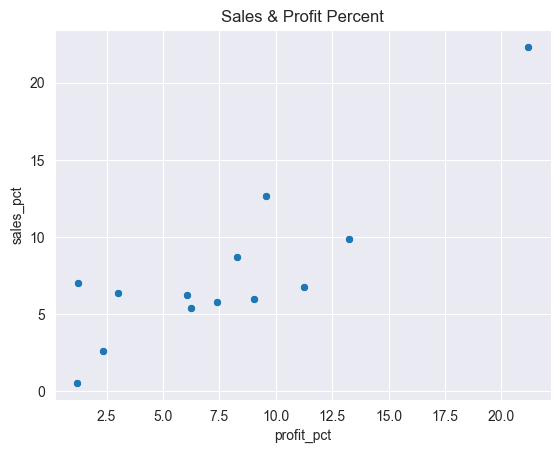

In [22]:
#Sales & Profit Percent
sns.scatterplot(data = df_grouped , x = "profit_pct", y = 'sales_pct')
plt.title("Sales & Profit Percent")


The business is growing consistently over time, with strong contribution from Technology, but there are clear inefficiencies in certain regions and categories where profit does not match sales

# Loss Analysis

In [23]:
#Loss-making sub_category
loss_sub_category = df.groupby('sub_category')['profit'].sum().round(2)
print(loss_sub_category[loss_sub_category < 0])

sub_category
Tables   -64083.39
Name: profit, dtype: float64


In [24]:
#Top 10 Loss making products
Loss_making_products = df.groupby(["sub_category",'product_name'])['profit'].sum().round(2)
Loss_making_products [Loss_making_products  <0].head(10).sort_values().reset_index()

,sub_category,product_name,profit
0,Accessories,"Belkin Memory Card, USB",-1264.93
1,Accessories,"Belkin Keyboard, Bluetooth",-704.40
2,Accessories,"Belkin Numeric Keypad, USB",-454.84
3,Accessories,"Enermax Numeric Keypad, USB",-266.00
4,Accessories,"Logitech Memory Card, Bluetooth",-240.66
5,Accessories,"Belkin Numeric Keypad, Erganomic",-185.25
6,Accessories,"Belkin Flash Drive, Erganomic",-30.79
7,Accessories,Logitech Keyboard K120,-19.60
8,Accessories,Case Logic 2.4GHz Wireless Keyboard,-12.00
9,Accessories,Kingston Digital DataTraveler 8GB USB 2.0,-2.02


 Loss is spread across multiple products rather than concentrated in one 

 Indicates pricing or discount strategy issue at category level

# Relationship Between Discount and Profit

In [25]:
#Create a discount bucket

df['discount_bucket'] = pd.cut(
    df['discount'],
    bins=[0.01,0.1,0.2,0.3,1],
    labels=['1-10%','10-20%','20-30%','30%+']
)   

Text(0.5, 1.0, 'Discount Make Loss')

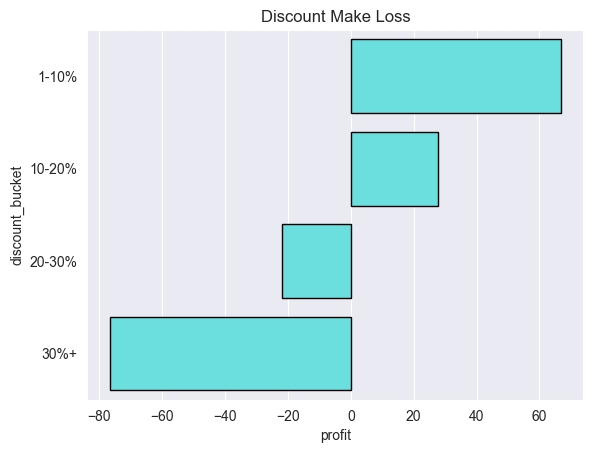

In [26]:
# Did the discount make loss

discount_make_loss = df.groupby('discount_bucket',observed=True)['profit'].mean().round(2).reset_index()
sns.barplot(
    discount_make_loss,
    x = 'profit',
    y='discount_bucket',
    color="#58F1F1",
    edgecolor='black')
plt.title('Discount Make Loss')



Products with >20% discount are mostly loss-making  
Profit margin is reduced

# High Shipping Cost vs Profit

In [27]:
df['shipping_cost_bucket'] = pd.cut(
    df['shipping_cost'],
    bins=[0, 50, 100, 300, 500, 1000],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

In [28]:
#Total profit by shipping_cost_bucket
df.groupby('shipping_cost_bucket', observed=True)['profit'] \
  .sum() \
  .sort_values(ascending=False) \
  .reset_index()

,shipping_cost_bucket,profit
0,Very Low,494175.13522
1,Medium,440985.14106
2,Low,301839.03090
3,High,154201.39050
4,Very High,77829.92360


In [29]:
#Avg profit by shipping_cost_bucket
df.groupby('shipping_cost_bucket', observed=True)['profit'] \
  .median() \
  .sort_values(ascending=False) \
  .reset_index()

,shipping_cost_bucket,profit
0,Very High,582.13500
1,High,355.44000
2,Medium,166.13700
3,Low,78.00000
4,Very Low,7.45755


In [30]:
df.groupby(['category', 'shipping_cost_bucket'],observed = True)['profit'].mean().reset_index()

,category,shipping_cost_bucket,profit
0,Furniture,Very Low,6.359161
1,Furniture,Low,42.709688
2,Furniture,Medium,136.210666
3,Furniture,High,280.612697
4,Furniture,Very High,433.206810
5,Office Supplies,Very Low,9.721361
6,Office Supplies,Low,93.132315
7,Office Supplies,Medium,155.640496
8,Office Supplies,High,527.806455
9,Office Supplies,Very High,1145.121758


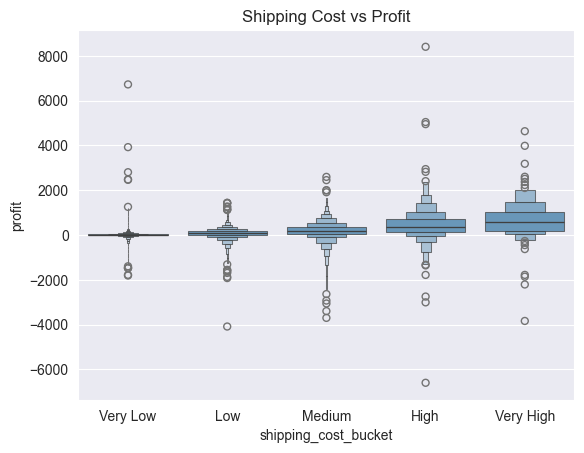

In [31]:
sns.boxenplot(x='shipping_cost_bucket', y='profit', data=df,alpha = 0.7)
plt.title('Shipping Cost vs Profit')
plt.show()

In [32]:
#Shipping cost profit summery
df.groupby('shipping_cost_bucket',observed=True)['profit']\
    .agg(['mean','median','min','max', 'count'])\
    .reset_index()

,shipping_cost_bucket,mean,median,min,max,count
0,Very Low,11.119052,7.45755,-1811.0784,6719.9808,44444
1,Low,78.257462,78.00000,-4088.3760,1435.5600,3857
2,Medium,175.272314,166.13700,-3701.8928,2591.9568,2516
3,High,439.320201,355.44000,-6599.9780,8399.9760,351
4,Very High,648.582697,582.13500,-3839.9904,4630.4755,120


High shipping cost orders generate significantly higher profit per order, but their overall volume is low. In contrast, low shipping cost orders occur in high volume but contribute minimal profit per order. 

The business is currently relying on high-volume, low-profit orders, which limits overall profitability. High-profit opportunities exist but are underutilized due to low order frequency. 

Focus on increasing the volume of high-value orders 

# Shipping Day VS Profit

In [33]:
#Finde the shipping_days
df['shipping_days'] = df['ship_date'] - df['order_date']

In [34]:
df['shipping_days'] = df['shipping_days'].dt.days

Text(0.5, 1.0, 'Shipping time vs profit')

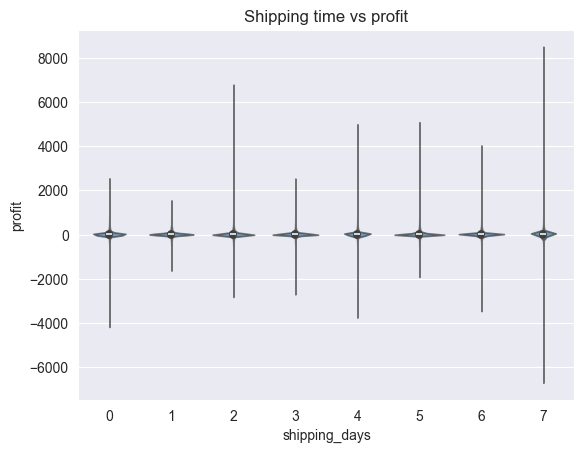

In [35]:
#Shipping time vs profit
df.groupby('shipping_days')['profit'].sum().round(2).sort_values(ascending= False).reset_index()

sns.violinplot(df,x='shipping_days',y = 'profit', alpha = 0.7 )
plt.title('Shipping time vs profit')


In [36]:
#Shipping time vs category
df.groupby('category').agg({"shipping_days":"mean", "profit":'sum'}).round(2).reset_index()

,category,shipping_days,profit
0,Furniture,3.99,286782.25
1,Office Supplies,3.96,518473.83
2,Technology,3.97,663778.73


In [37]:
#Region vs Shipping time
df.groupby('region').agg({"shipping_days":"mean", "profit":'sum'}).round(2).reset_index()

,region,shipping_days,profit
0,Africa,3.91,88871.63
1,Canada,3.68,17817.39
2,Caribbean,3.97,34571.32
3,Central,4.03,311403.98
4,Central Asia,4.01,132480.19
5,EMEA,3.93,43897.97
6,East,3.91,91522.78
7,North,4.03,194597.95
8,North Asia,3.91,165578.42
9,Oceania,3.93,121666.64


Orders with 4–5 shipping days generate highest profit (₹418K, ₹319K) 

Moderate shipping time is associated with higher profitability 

Optimize for cost-efficient shipping instead of fastest delivery 

# Profit Margin

In [38]:
#Marginal Distribution
df['profit_margin'] = np.where(df['sales'] != 0, df['profit']/df['sales'], 0)

In [39]:
#Profit Margin by category

category_margin_percent = (df.groupby('category')['profit'].sum()/df.groupby('category')['sales'].sum())*100
category_margin_percent.round(2).sort_values(ascending= False).reset_index()

,category,0
0,Technology,13.99
1,Office Supplies,13.69
2,Furniture,6.98


In [40]:
#Profit Margin by Sub category

sub_category_margin_percent = ((df.groupby('sub_category')['profit'].sum()/df.groupby('sub_category')['sales'].sum())*100)
sub_category_margin_percent.round(2).sort_values(ascending= False).reset_index()

,sub_category,0
0,Paper,24.23
1,Labels,20.44
2,Envelopes,17.32
3,Accessories,17.30
4,Copiers,17.13
5,Binders,15.68
6,Art,15.57
7,Appliances,14.01
8,Fasteners,13.84
9,Phones,12.70


In [41]:
#Profit Margin by region
region_margin_percent = ((df.groupby('region')['profit'].sum()/df.groupby('region')['sales'].sum())*100)
region_margin_percent.round(2).sort_values(ascending= False).reset_index()

,region,0
0,Canada,26.62
1,North Asia,19.52
2,Central Asia,17.60
3,North,15.59
4,West,14.94
5,East,13.48
6,Africa,11.34
7,Oceania,11.06
8,Central,11.03
9,Caribbean,10.66


Text(0.5, 1.0, 'Profit Marginal Distribution')

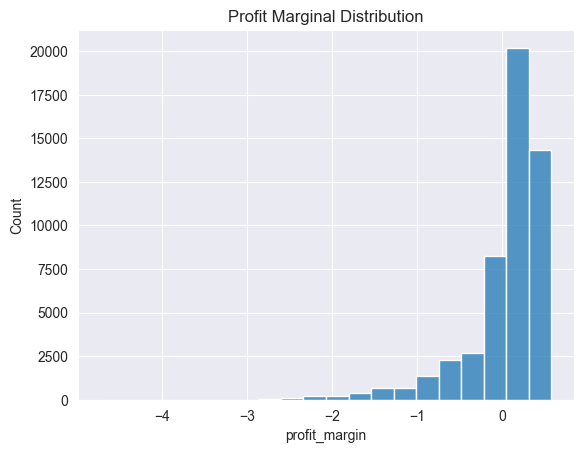

In [42]:
#Find the Profit Marginal Distribution
sns.histplot(data= df, x = 'profit_margin',bins = 20)
plt.title("Profit Marginal Distribution")

# Regression Model

In [43]:
# Copy Data
df_clean = df.copy()


df_clean['sales_log'] = np.log1p(df_clean['sales'])
df_clean['profit_log'] = np.log1p(df_clean['profit'] - df_clean['profit'].min() + 1)


In [44]:
# Removed outliers using IQR to reduce noise and improve model accuracy

outlier_cols = ['sales_log', 'profit_log', 'shipping_cost']

mask = np.ones(len(df_clean), dtype=bool)

for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask &= (df_clean[col] >= lower) & (df_clean[col] <= upper)

df_clean = df_clean[mask]

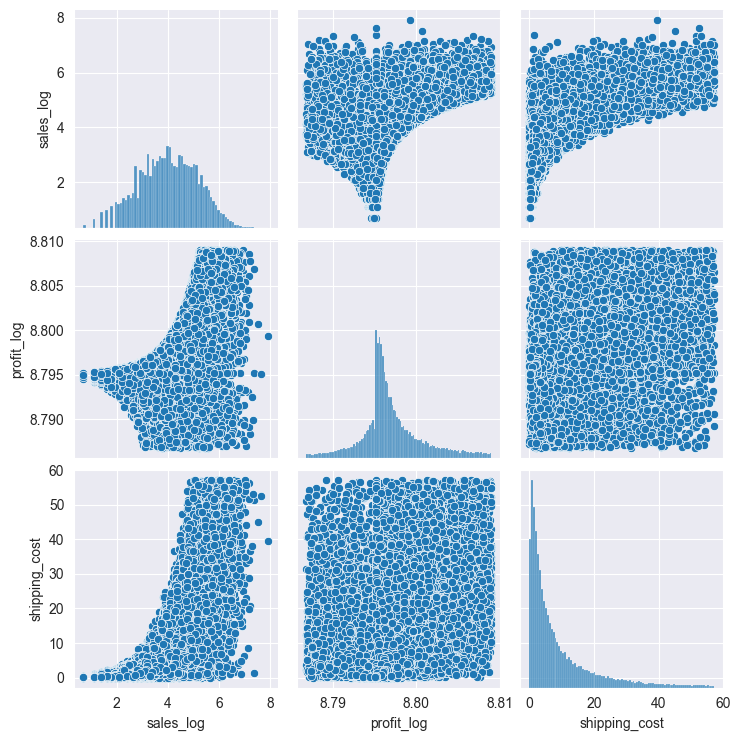

In [45]:
# EDA 

sns.pairplot(df_clean[['sales_log', 'profit_log', 'shipping_cost']])

Text(0.5, 1.0, 'Correlation eatmap')

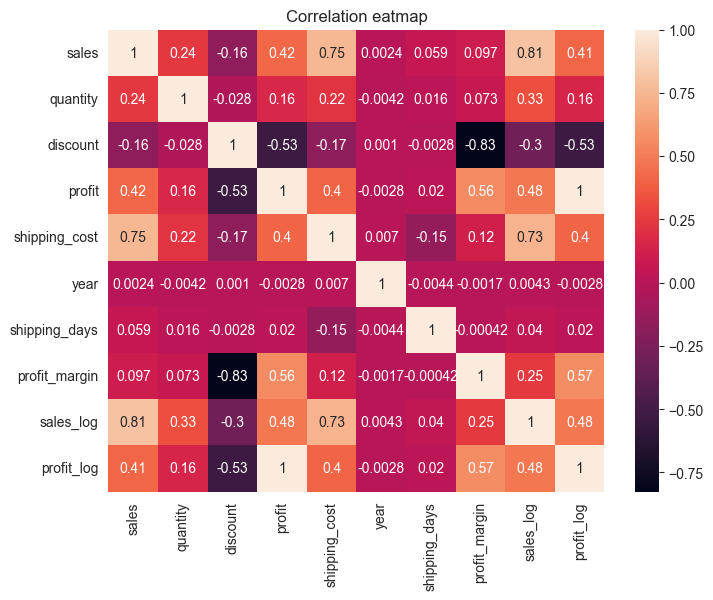

In [46]:
# Checked multicollinearity using correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True)
plt .title("Correlation eatmap")


In [47]:
# Check correlation
df_clean[['sales_log', 'profit_log']].corr()

,sales_log,profit_log
sales_log,1.000000,0.481559
profit_log,0.481559,1.000000


In [48]:
from sklearn import linear_model
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split



x = df_clean[['sales_log']]
y = df_clean['profit_log']

#  Train-Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2 , random_state= 42)

# Model Training
model = linear_model.LinearRegression()
model.fit(x_train, y_train)

# Predict
y_pred = model.predict(x_test)


In [49]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# How well the model fit
print("R2:", r2_score(y_test, y_pred))

# Finde the RMES and MAE
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))


R2: 0.2194031243925314
RMSE: 0.0033140911675303554
MAE: 0.0023248340768420995


In [50]:
#Creat a Second model
model2 = linear_model.LinearRegression()

X = df_clean[['sales_log', 'discount', 'shipping_cost']]
Y = df_clean['profit_log']

#  Train-Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state= 42) 

# Train model
model2.fit(X_train, Y_train)
Y_pred = model2.predict(X_test)


In [51]:
# How well the model fit with the predictied

print("R2:", r2_score(Y_test, Y_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, Y_pred)))
print("MAE:", mean_absolute_error(Y_test, Y_pred))

R2: 0.3940064500529903
RMSE: 0.00292001476720529
MAE: 0.0020863715928898857


Model explains around 40% of profit variation

In [52]:
feature_names = ['sales', 'discount', 'shipping_cost']

for name, coef in zip(['sales_log'], model.coef_):
    print(f"{name} impact on profit:", coef)
print("Interpretation: As sales increase, profit also increases.")

sales_log impact on profit: 0.0016194301238430786
Interpretation: As sales increase, profit also increases.


# FINAL INSIGHTS:
  * Sales positively impact profit
  * Discount negatively impacts profit
  * High shipping cost reduces profitability
  * Model shows moderate predictive power R2 = 0.4

# LIMITATION:
* Model may not capture complex relationships

In [53]:
df.replace([np.inf, -np.inf], None, inplace=True)

In [54]:
from sqlalchemy import create_engine

username = "root"
password = "1234"
host = "localhost"
port = "3306"
database = "super_store"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

table_name = "super_store_analysis"
df.to_sql(name = table_name,con= engine, if_exists="replace", index=False)

pd.read_sql("SELECT * FROM super_store_analysis LIMIT 5;", engine)


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,quantity,discount,profit,shipping_cost,order_priority,year,discount_bucket,shipping_cost_bucket,shipping_days,profit_margin
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,2,0.0,106.140,35.46,Medium,2011,None,Very Low,5,0.260147
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,3,0.1,36.036,9.72,Medium,2011,1-10%,Very Low,7,0.300300
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,4,0.0,29.640,8.17,High,2011,None,Very Low,4,0.449091
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,3,0.5,-26.055,4.82,High,2011,30%+,Very Low,4,-0.579000
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,5,0.1,37.770,4.70,Medium,2011,1-10%,Very Low,7,0.331316


# Key Insights
* Profit showed significant growth in 2014, driven by the Technology category.
* Furniture contributes a high share of sales but relatively lower profit, indicating low margins.
* High-value orders are associated with higher shipping costs and higher profit.
* Profit distribution is skewed, with few high-profit orders.


# Root Causes
* Furniture category is impacted by higher discounts and shipping costs.
* High shipping costs reduce overall profitability for certain orders.  
* Low-margin products are more sensitive to logistics costs


# Business Recommendations
* Optimizing discounts and shipping strategies can significantly improve profitability.
* Improve shipping efficiency for bulky or low-margin products.
* Focus on high-margin categories like Technology.
* Consider minimum order value thresholds to offset high shipping costs.